Taxi Fare Prediction Using Regression and Exploratory Data Analysis


In [1]:
#Library Importation
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df =pd.read_csv('/content/drive/MyDrive/Colab Notebooks/taxi_trip_pricing.csv')

In [4]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [8]:
data = df.copy()

In [9]:
# Filling missing values
data['Trip_Distance_km']= data['Trip_Distance_km'].fillna(data['Trip_Distance_km'].median())

In [10]:
data['Passenger_Count']= data['Passenger_Count'].fillna(data['Passenger_Count'].median())
data['Base_Fare']= data['Base_Fare'].fillna(data['Base_Fare'].median())
data['Per_Km_Rate']= data['Per_Km_Rate'].fillna(data['Per_Km_Rate'].median())
data['Per_Minute_Rate']= data['Per_Minute_Rate'].fillna(data['Per_Minute_Rate'].median())
data['Trip_Duration_Minutes']= data['Trip_Duration_Minutes'].fillna(data['Trip_Duration_Minutes'].median())
data['Trip_Price']= data['Trip_Price'].fillna(data['Trip_Price'].median())
data['Time_of_Day'] = data['Time_of_Day'].fillna(data['Time_of_Day'].mode()[0])
data['Day_of_Week'] = data['Day_of_Week'].fillna(data['Day_of_Week'].mode()[0])
data['Traffic_Conditions'] = data['Traffic_Conditions'].fillna(data['Traffic_Conditions'].mode()[0])
data['Weather'] = data['Weather'].fillna(data['Weather'].mode()[0])

In [11]:
df = data

In [12]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [ ]:
#EDA AND VISUALISATION

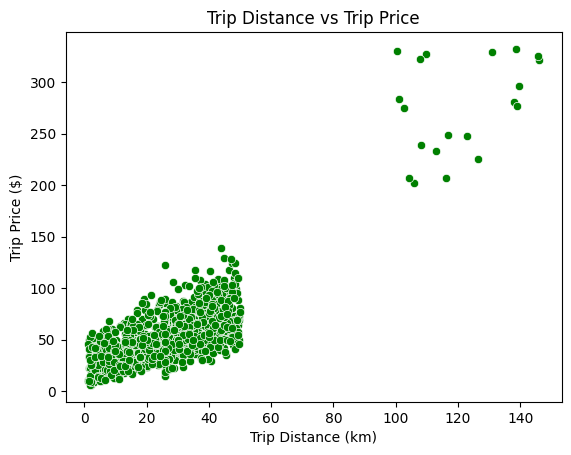

In [13]:
sns.scatterplot(x='Trip_Distance_km', y='Trip_Price', data=df, color = 'green')

plt.title('Trip Distance vs Trip Price')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Trip Price ($)')
plt.show()

# The visual shows that the shorter the distance the lower the fare price as observed in the largerly dense portion
# of the plot however the data also implies that the farther the distance, the higher the fare price as seen below
# having above $200 cost.


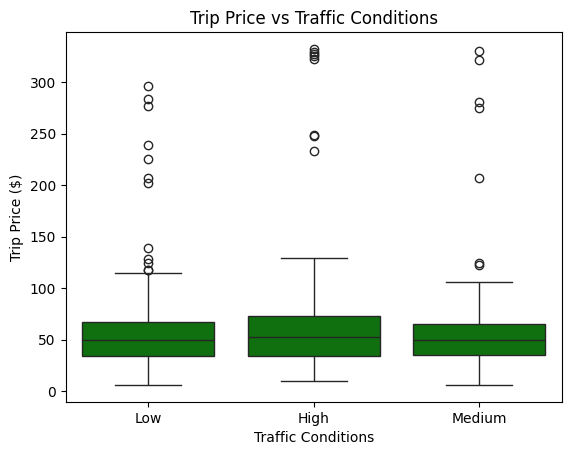

In [14]:
sns.boxplot(x='Traffic_Conditions', y='Trip_Price', data=df, color = 'green')
plt.title('Trip Price vs Traffic Conditions')
plt.xlabel('Traffic Conditions')
plt.ylabel('Trip Price ($)')
plt.show()

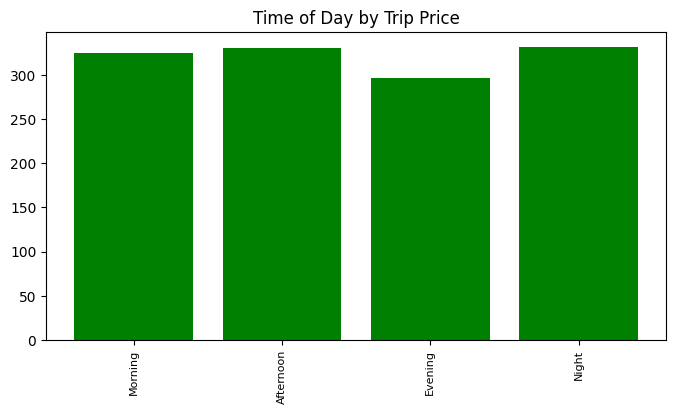

In [15]:
plt.figure(figsize=(8,4))
plt.bar('Time_of_Day', 'Trip_Price', data=df, color = 'green')
plt.xticks(rotation=90, fontsize=8)
plt.title('Time of Day by Trip Price')
plt.show()

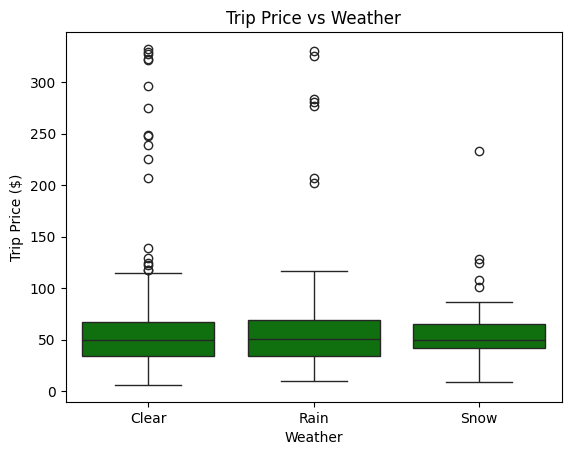

In [16]:
sns.boxplot(x='Weather', y='Trip_Price', data=df, color = 'green')
plt.title('Trip Price vs Weather')
plt.xlabel('Weather')
plt.ylabel('Trip Price ($)')
plt.show()

#

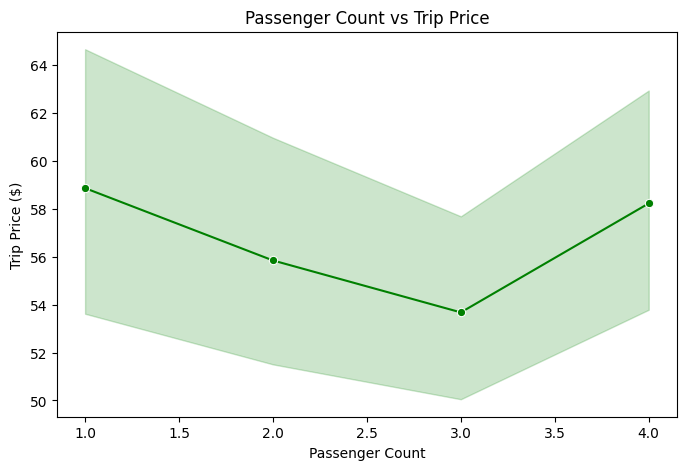

In [54]:
df_sorted = df.sort_values('Passenger_Count')
plt.figure(figsize=(8,5))

sns.lineplot(
    x='Passenger_Count',
    y='Trip_Price',
    data=df_sorted,
    marker='o',
    color='green'
)

plt.title('Passenger Count vs Trip Price')
plt.xlabel('Passenger Count')
plt.ylabel('Trip Price ($)')

plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

In [31]:
df_encoded = pd.get_dummies(df, columns=['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], drop_first=True)

In [32]:
print("Final Shape after encoding:", df_encoded.shape)

Final Shape after encoding: (1000, 15)


In [36]:
df_encoded.head()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,False,True,False,False,True,False,False,False
1,47.59,1.0,3.52,0.62,0.43,40.57,50.0745,False,False,False,False,False,False,False,False
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,True,False,False,True,False,False,False,False
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,True,False,False,False,True,False,False,False
4,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,True,False,False,False,False,False,False,False


In [46]:
X = df_encoded.drop('Trip_Price', axis=1)
y = df_encoded['Trip_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [47]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "SVR": SVR()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])
    print(f"{name:20} → MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f} | R²: {r2:.4f}")

Linear Regression    → MAE: $9.80 | RMSE: $13.86 | R²: 0.7687
Decision Tree        → MAE: $8.69 | RMSE: $11.19 | R²: 0.8494
Random Forest        → MAE: $5.32 | RMSE: $7.50 | R²: 0.9323
SVR                  → MAE: $14.51 | RMSE: $21.52 | R²: 0.4428


In [48]:
# Best model is Random Forest having the lowest MAE and RMSE value and the highest R²
best_model = models["Random Forest"]

In [73]:
ope_trip = pd.DataFrame({
    'Trip_Distance_km': [15],
    'Traffic_Conditions': ['Medium'],
    'Day_of_Week': ['Monday'],
    'Time_of_Day': ['Morning'],
    'Weather': ['Sunny'],
    'Base_Fare': [2.51],
    'Passenger_Count': [1],
    'Per_Km_Rate': [0.80],
    'Per_Minute_Rate':[0.25],
    'Trip_Duration_Minutes':[52.14]


})

In [82]:
ope_trip_encoded = pd.get_dummies(ope_trip, columns=['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'])

In [83]:
ope_trip_encoded.head()

,Trip_Distance_km,Base_Fare,Passenger_Count,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Morning,Day_of_Week_Monday,Traffic_Conditions_Medium,Weather_Sunny
0,15,2.51,1,0.8,0.25,52.14,True,True,True,True


In [85]:
model_columns = X.columns
ope_trip_encoded = ope_trip_encoded.reindex(columns=model_columns, fill_value=0)

In [86]:
pred_taxi_price = best_model.predict(ope_trip_encoded)
print(f"Predicted Taxi Price: ${pred_taxi_price[0]:,.2f}")

Predicted Taxi Price: $29.92


In [90]:
import joblib
import os

os.makedirs('models', exist_ok=True)

best_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [91]:
joblib.dump(best_model, 'models/trip_price_model.pkl')
joblib.dump(X.columns.tolist(), 'models/trip_feature_names.pkl')

print("✅ Model Saved Successfully!")
print("📁 Files created in 'models/' folder")

✅ Model Saved Successfully!
📁 Files created in 'models/' folder
